In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum

yu.setpath('check_helicity_priyajit')

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
enss=['b','c','d']
ens='b'

In [2]:
path=f'pkl/analysis_c2pt/reg_ignore/ens2pars_jk_meffnst_selected.pkl'
[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl(path)

In [3]:
ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
for ens in enss:
    basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
    path=f'{basepath}disc_2pt.h5'
    with h5py.File(path) as f:
        moms_2pt=yu.moms2list(f['moms'])
        c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
        
    ens2moms_2pt[ens]=moms_2pt
    ens2c2pt[ens]=c2pt
    ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
    ens2Njk[ens]=len(c2pt)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [22]:
c2pt=ens2c2pt0['b']
yu.jackme_un2str(c2pt[:,10:20],forceResult=None)

factor=-1j/2

ens='b'
path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA/{yu.ens2full[ens]}/data_merge/disc_0,0,0,0,0,0.h5'
with h5py.File(path) as f:
    tf=10
    t=f[f'data/j+;disc_{tf}'][:]
    t=t[:,:,0,projs.index('Pz'),inserts.index('tz')]
    c3pt=yu.jackknife(np.real(t/factor))
    
    ratio=c3pt/c2pt[:,tf:tf+1]
    print(yu.jackme_un2str(ratio,precision=3))

[0.00119(495), 0.00114(484), -0.00184(488), -0.00345(481), 0.00231(457), 0.00014(490), -0.00517(501), -0.00060(464), -0.00739(494), 0.00375(494), -0.00707(499)]


In [27]:
path='/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA_xcheckGiannis/cB211.072.64/data_avgsrc/a0500/disc_0,0,0,0,0,0.h5'
with h5py.File(path) as f:
    t=f['data/j+;disc_10'][:]
    print(t[:,0,projs.index('Pz'),inserts.index('tz')])

[ 1.13186803e-10+1.31209079e-11j -2.59881106e-11+3.27563371e-12j
  4.94908274e-11+1.07924942e-10j -5.55462483e-11+2.22952670e-11j
 -5.48484302e-11-7.30076495e-11j -3.22786770e-12+4.87529215e-12j
  2.20037753e-12+3.40546524e-11j  1.11623467e-12+8.48482290e-11j
  4.81947547e-12-1.22758572e-10j  4.20773851e-11-1.62305244e-11j
 -4.50993426e-11+4.58811206e-11j]


8 [-0.0002(42), 0.0028(40), 0.0005(41), -0.0014(41), 0.0049(37), 0.0012(40), -0.0005(41), 0.0000(39), -0.0037(40)]
       1  -0.5541   0.1261   0.0955 0.003075  0.02469 0.008092  0.01744  0.01002
 -0.5541        1  -0.4956   0.1035  0.01433 -0.06983  0.08036 -0.03003   0.0149
  0.1261  -0.4956        1  -0.5325   0.1406  0.09102 -0.05781  0.07201 -0.03354
  0.0955   0.1035  -0.5325        1   -0.515  0.08617  0.04291 -0.04435  0.02627
0.003075  0.01433   0.1406   -0.515        1  -0.5072   0.1928 -0.01948   0.0403
 0.02469 -0.06983  0.09102  0.08617  -0.5072        1   -0.598   0.2647 -0.05444
0.008092  0.08036 -0.05781  0.04291   0.1928   -0.598        1    -0.54   0.1875
 0.01744 -0.03003  0.07201 -0.04435 -0.01948   0.2647    -0.54        1  -0.5627
 0.01002   0.0149 -0.03354  0.02627   0.0403 -0.05444   0.1875  -0.5627        1
10 [-0.0038(61), 0.0048(60), 0.0008(62), -0.0018(59), 0.0043(56), 0.0038(60), -0.0056(60), 0.0034(59), -0.0065(61), 0.0073(61), -0.0094(62)]
       1  -0.56

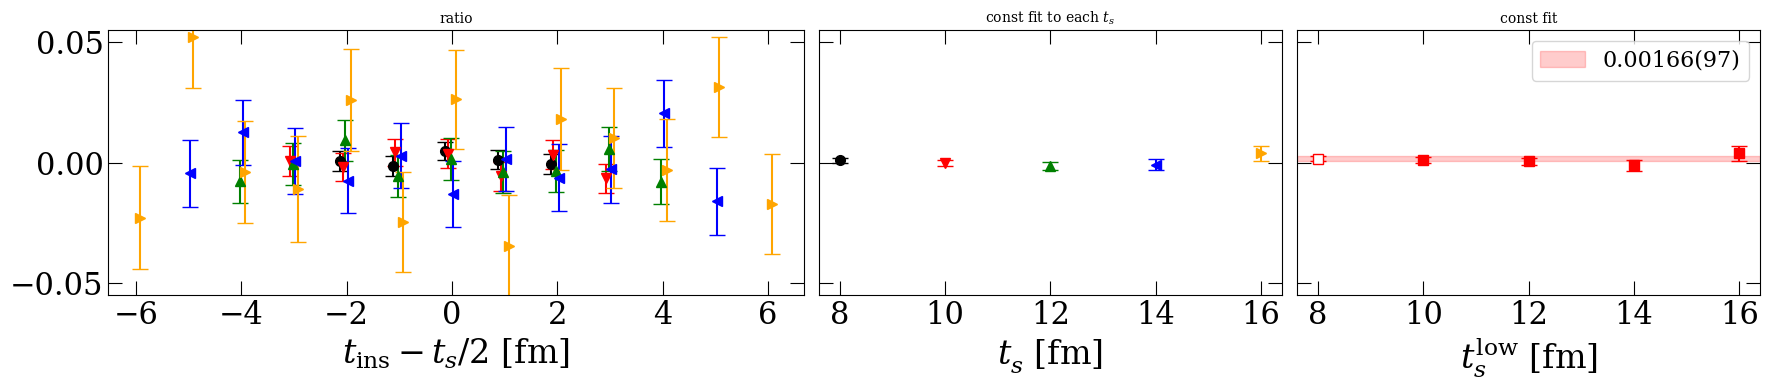

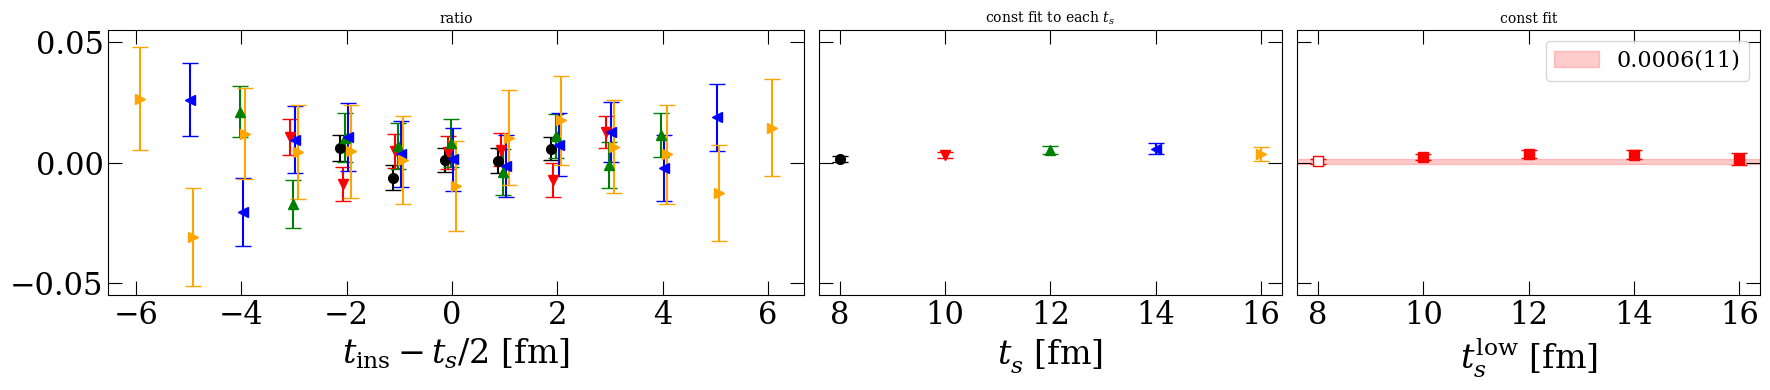

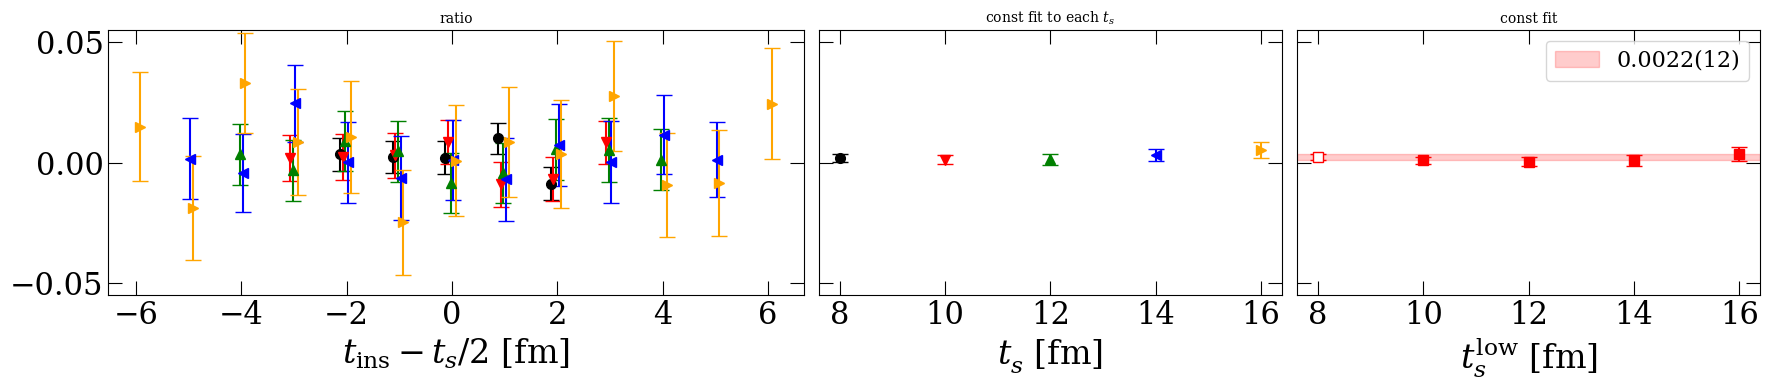

In [7]:

cases=['']

for ens in ['b','c','d']:
    case2dic={}
    for case in cases:
        path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA{case}/{yu.ens2full[ens]}/data_merge/disc_0,0,0,0,0,0.h5'

        factor=-1j * ens2pars_jk_meff2st[ens][:,0]/2

        c2pt=ens2c2pt0[ens]

        tfs=np.arange(8,22,2)
        tf2ratio={}
        with h5py.File(path) as f:
            for tf in tfs:
                t=f[f'data/js;disc_{tf}'][:]
                t=t[:,:,0,projs.index('Pz'),inserts.index('tz')]
                t=yu.jackknife(np.real(t/factor[:,None]))
                t=t/c2pt[:,tf:tf+1]
                tf2ratio[tf]=t
                
                print(tf,yu.jackme_un2str(t))
                cov=yu.jackmec(t)[-1]
                print(yu.formatMatrix(yu.cov2correlation(cov)))

        fits_band=yu.doFits_3pt_band(tf2ratio,[2],corrQ=False)
        fits_const=yu.doFits_3pt('const',tf2ratio,[8,10,12,14,16],[3],symmetrizeQ=False,corrQ=True)
        # tfmin=gett(0.6); tcmin=gett(0.3)
        fit_const_MA=yu.doMA_3pt(fits_const,fitlabels=(8,3))
        dic={
            'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,fits_band,fits_const,None,None],
            'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,fit_const_MA,None,None],
            'rainbow:[tfmin,tfmax,tcmin,dt]':[8,16,2,2],
            'fit_band:[tfmin,tfmax,tcmin_min,tcmin_max,dtf,dtc]':[8,16,None,None,2,1],
            'xyunit':[1,1],
        }
        case2dic[case]=dic

    fig,axs=yu.makePlot_3pt([case2dic[case] for case in cases],shows=['rainbow','fit_band','fit_const'],colors_rainbow=['black','r','g','b','orange'],sharey=True)
    ax=axs[0,0]
    # yu.addRowHeader(axs,['full','0g5H','0g5H_0bw'])
    ax.set_ylim([-0.055,0.055])
    yu.finalizePlot()

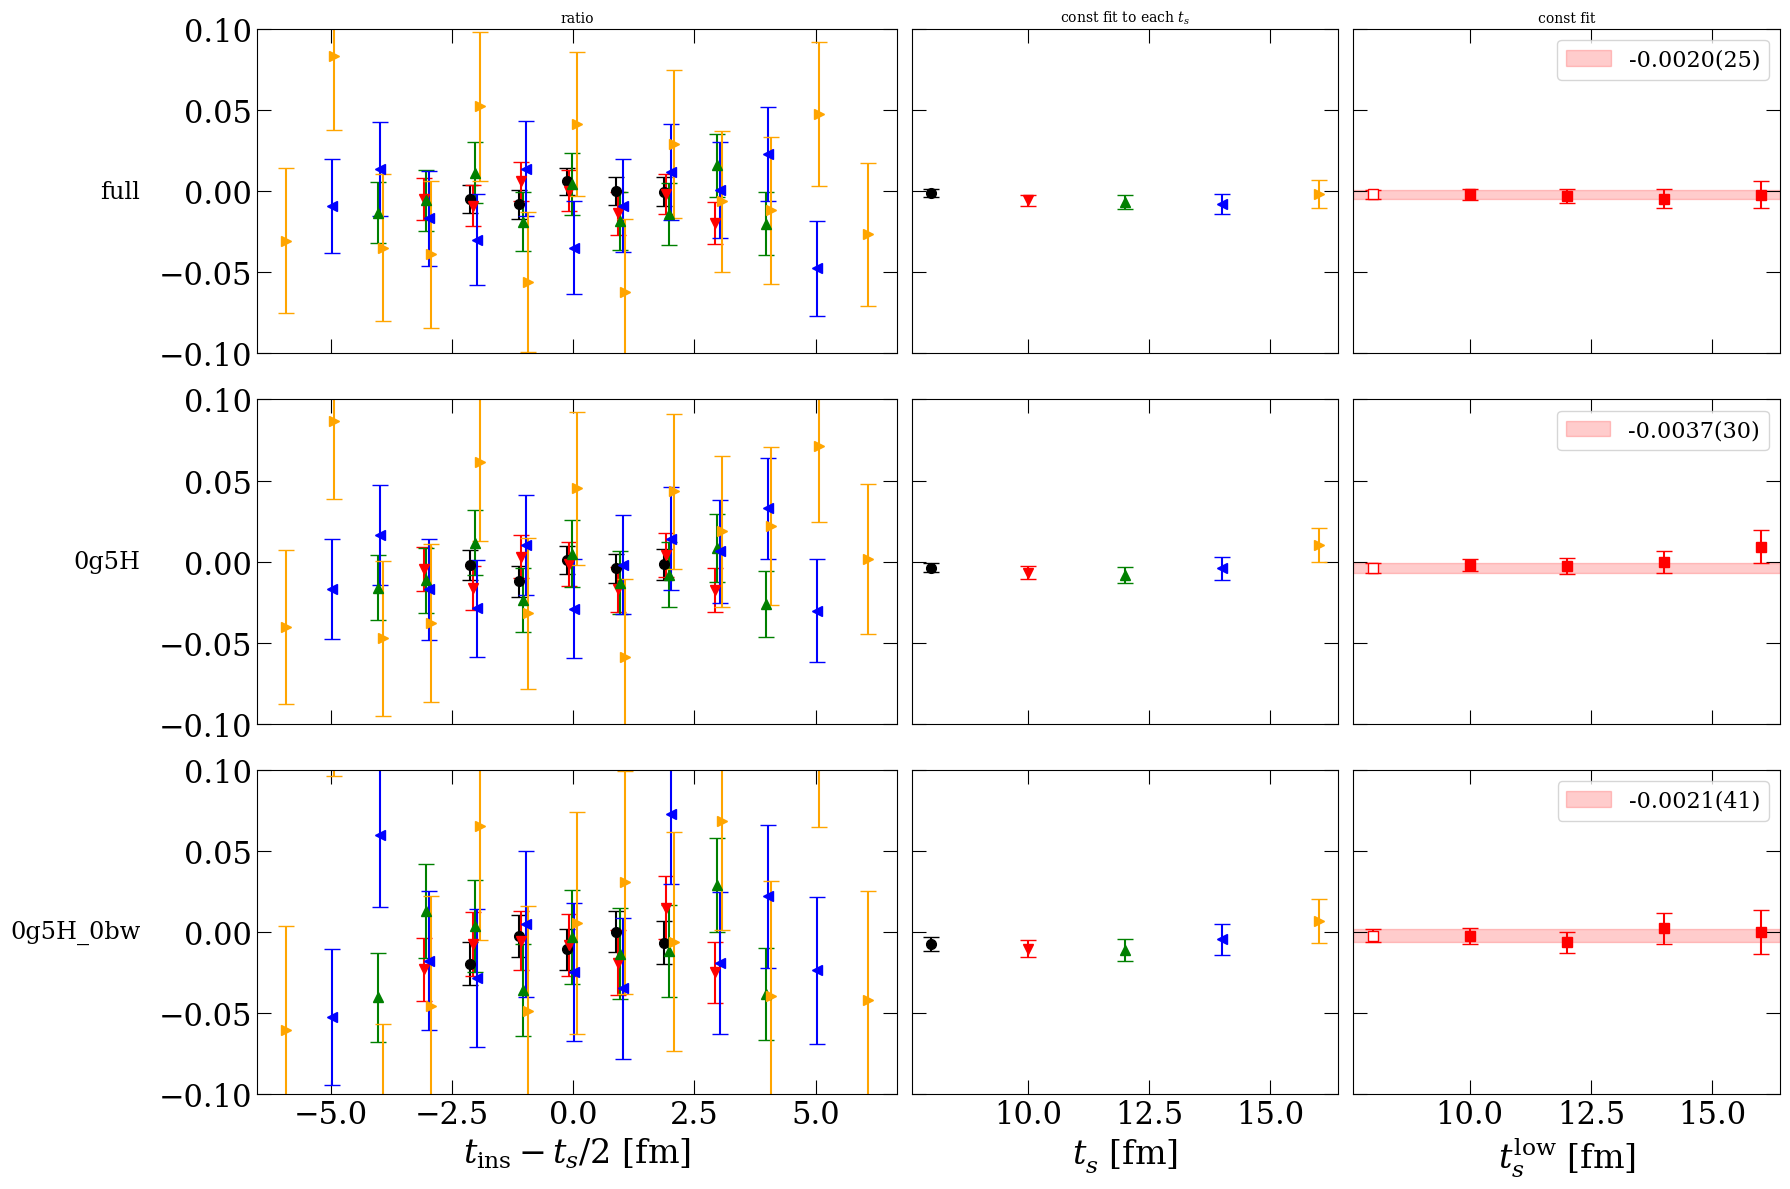

In [7]:
cases=['','_0g5H','_0bw_0g5H']

case2dic={}
for case in cases:
    path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA{case}/cB211.072.64/data_merge/disc_0,0,0,0,0,0.h5'

    factor=-1j * ens2pars_jk_meff2st[ens][:,0]/2

    c2pt=ens2c2pt0[ens]

    tfs=np.arange(8,22,2)
    tf2ratio={}
    with h5py.File(path) as f:
        for tf in tfs:
            t=f[f'data/j+;disc_{tf}'][:]
            t=t[:,:,0,projs.index('Pz'),inserts.index('tz')]
            t=yu.jackknife(np.real(t/factor[:,None]))
            t=t/c2pt[:,tf:tf+1]
            tf2ratio[tf]=t

    fits_band=yu.doFits_3pt_band(tf2ratio,[2],corrQ=False)
    fits_const=yu.doFits_3pt('const',tf2ratio,[8,10,12,14,16],[3],symmetrizeQ=False,corrQ=True)
    # tfmin=gett(0.6); tcmin=gett(0.3)
    fit_const_MA=yu.doMA_3pt(fits_const,fitlabels=(8,3))
    dic={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,fits_band,fits_const,None,None],
        'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,fit_const_MA,None,None],
        'rainbow:[tfmin,tfmax,tcmin,dt]':[8,16,2,2],
        'fit_band:[tfmin,tfmax,tcmin_min,tcmin_max,dtf,dtc]':[8,16,None,None,2,1],
        'xyunit':[1,1],
    }
    case2dic[case]=dic

fig,axs=yu.makePlot_3pt([case2dic[case] for case in cases],shows=['rainbow','fit_band','fit_const'],colors_rainbow=['black','r','g','b','orange'],sharey=True)
ax=axs[0,0]
yu.addRowHeader(axs,['full','0g5H','0g5H_0bw'])
ax.set_ylim([-0.1,0.1])
yu.finalizePlot()

# xcheck Ferenc

In [3]:
path='/p/project1/ngff/pittler/crosschech_helicity/pi_i0xyz_results.h5'
yu.print_hdf5_structure(path)

/: 6 groups, ['tsep10', 'tsep12', 'tsep14', 'tsep4']; 
/tsep10: 40 datasets, ['pi_i00', 'pi_i00_polarizedx', 'pi_i00_polarizedy', 'pi_i00_polarizedz']; 
pi_i00: (11,); [-7.20156286e-12+6.80804801e-11j -5.90722298e-12+6.60559625e-11j
  3.05549211e-11+8.57669327e-11j  3.61778289e-12+2.90410162e-11j
  7.41583826e-12+8.96715279e-11j  2.95671231e-11+4.16028565e-11j
  1.74041808e-11+1.02085101e-10j  1.44933409e-11+2.17371323e-10j
 -1.53837043e-11+1.42464594e-10j -3.14900249e-11+1.34811854e-10j
  1.13779550e-11+9.64411240e-11j]


In [37]:
path='/p/project1/ngff/pittler/crosschech_helicity/pi_i0xyz_results.h5'
with h5py.File(path) as f:
    print(f['tsep8']['pi_i0y_polarizedy'][:4])
    
path='/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA/cB211.072.64/data_avgsrc/a0500/disc_0,0,0,0,0,0.h5'
with h5py.File(path) as f:
    t=f['data/j+;disc_8'][:4,0,projs.index('Py'),inserts.index('ty')]
    print(t)

[-1.21150655e-11+5.40082656e-11j  3.42204138e-12+3.30535180e-11j
  1.63312721e-10-9.43768656e-11j -4.98469603e-11+5.03080789e-11j]
[ 1.21150655e-11-5.40082656e-11j -3.42204138e-12-3.30535180e-11j
 -1.63312721e-10+9.43768656e-11j  4.98469603e-11-5.03080789e-11j]


In [32]:
for proj in projs:
    for insert in inserts:
        path='/p/project1/ngff/pittler/crosschech_helicity/pi_i0xyz_PT_results.h5'
        with h5py.File(path) as f:
            insert1=insert.replace('t','0')
            proj1='' if proj in ['P0'] else f'_polarized{proj[-1]}' 
            t1=f['tsep8'][f'pi_i{insert1}{proj1}'][:]
            
        path='/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA/cB211.072.64/data_avgsrc/a0500/disc_0,0,0,0,0,0.h5'
        with h5py.File(path) as f:
            t2=f['data/j+;disc_8'][:,0,projs.index(proj),inserts.index(insert)]

        dt=t1-t2
        print(proj,insert,np.sum(np.abs(dt)),t1[:1],t2[:1])

P0 tt 4.204158174362477e-17 [-1.22169506e-10+1.52130131e-10j] [-1.2216951e-10+1.52130133e-10j]
P0 tx 7.213316675522776e-17 [-8.65073521e-11+6.13376568e-10j] [-8.65073505e-11+6.13376573e-10j]
P0 ty 7.740977810885039e-17 [-1.73608232e-10+2.44376573e-10j] [-1.73608231e-10+2.44376581e-10j]
P0 tz 6.248618904134327e-17 [-1.12607435e-10+1.13524547e-10j] [-1.12607437e-10+1.1352455e-10j]
P0 xx 4.773063874678844e-17 [3.35387615e-11+1.22215217e-10j] [3.35387619e-11+1.22215212e-10j]
P0 xy 3.048329154522256e-17 [3.2781415e-11+2.65946181e-11j] [3.27814124e-11+2.6594617e-11j]
P0 xz 4.873013233695373e-17 [3.44717294e-11+3.91422196e-10j] [3.44717319e-11+3.91422187e-10j]
P0 yy 3.9067024425434305e-17 [3.63751945e-11-1.27376315e-11j] [3.63751963e-11-1.27376287e-11j]
P0 yz 3.092270616277492e-17 [7.94613536e-11-8.20002479e-10j] [7.94613538e-11-8.2000248e-10j]
P0 zz 4.025663089401949e-17 [5.22555503e-11-2.61607717e-10j] [5.22555514e-11-2.61607716e-10j]
Px tt 9.670378328029043e-18 [-1.73698274e-11-2.35001489e